# MoG40 Dataset

## Setup


In [1]:
import math, time, os, warnings
import numpy as np
import matplotlib; import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.optimize import linear_sum_assignment

try:
    import ot as pot; HAS_POT = True
    print("POT found — Sinkhorn available.")
except ImportError:
    HAS_POT = False
    print("POT not found — Sinkhorn skipped.")

matplotlib.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
print(f"NumPy {np.__version__}")


POT found — Sinkhorn available.
NumPy 2.0.0


In [ ]:
# ── Target ────────────────────────────────────────────────────────────────────
K_MODES    = 40
SIGMA_COMP = 1.0
SIGMA      = math.sqrt(2)   # exp(-2V/sigma^2) = exp(-V) = pi

# ── Sampler step size & horizon ────────────────────────────────────
DT         = 0.01
T_END      = 20.0
N_STEPS    = int(T_END / DT)

# ── Particle count & seeds ─────────────────────────────────────────
N_PARTICLES = 2500
SEEDS       = [0, 1, 2]

# ── FLMC ──────────────────────────────────────────────────────────────────────
ALPHA_FLMC = 1.5

# ── LSBMC jump distribution: Unif[a, b] ──────────────────────────────────────
LAM        = 1.0
A_JUMP     = 4.0
B_JUMP     = 15.0
M_PHI      = 64
STATE_CLIP = 65.0
S_CLIP     = 80.0

# ── Metrics & output ──────────────────────────────────────────────────────────
W2_SUB       = 200
METRIC_EVERY = 50
N_REF        = 3000

OUT_DIR = "mog40_output"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"Steps: {N_STEPS}  |  Particles: {N_PARTICLES}  |  M_phi: {M_PHI}")
print(f"Jump interval: [{A_JUMP}, {B_JUMP}]  |  lambda={LAM}")
print(f"Metric checkpoints: {N_STEPS // METRIC_EVERY + 1}")
print(f"Output directory: {OUT_DIR}/")


Steps: 2000  |  Particles: 2500  |  M_phi: 64
Jump interval: [4.0, 15.0]  |  lambda=1.0
Metric checkpoints: 41
Output directory: mog40_output/


### Mode Centers

$$
\mu_1,\dots,\mu_{40} \;\overset{\text{iid}}{\sim}\; \mathrm{Unif}([-40,40]^2),
\quad \text{seed}=0\text{ (fixed)}.
$$

Target density: $\pi(x)\propto\sum_{k=1}^{40}\exp(-\|x-\mu_k\|^2/2)$,
all components with identity covariance $I_2$.


In [3]:
_rng_modes = np.random.default_rng(0)
MU = _rng_modes.uniform(-40.0, 40.0, size=(K_MODES, 2))
print(f"MU.shape = {MU.shape}")


MU.shape = (40, 2)


### Jump: $\mathrm{Unif}[a, b]$

=== Nearest-Neighbour Distance Statistics ===
  mean   = 7.14
   10%   = 2.49
   25%   = 4.27
   50%   = 6.78
   75%   = 8.87
   90%   = 11.65
   95%   = 14.82
   99%   = 15.89
  max    = 16.02

Fraction of modes with NN within a=4.0 and b=15.0: 78%


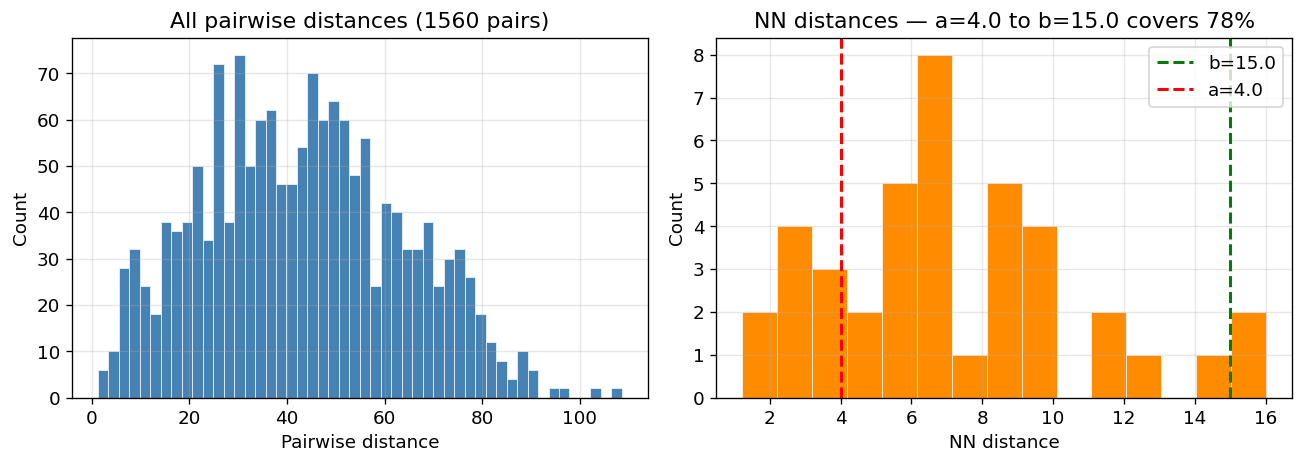

In [4]:
diff_all  = MU[:, None, :] - MU[None, :, :]
pdist_mat = np.sqrt(np.sum(diff_all**2, axis=-1))
mask_off  = ~np.eye(K_MODES, dtype=bool)
pairwise  = pdist_mat[mask_off]
nn_dists  = np.array([pdist_mat[k, mask_off[k]].min() for k in range(K_MODES)])

qs = [10, 25, 50, 75, 90, 95, 99]
print("=== Nearest-Neighbour Distance Statistics ===")
print(f"  mean   = {nn_dists.mean():.2f}")
for q, v in zip(qs, np.percentile(nn_dists, qs)):
    print(f"  {q:3d}%   = {v:.2f}")
print(f"  max    = {nn_dists.max():.2f}")
pct_covered = (A_JUMP <= nn_dists) & (nn_dists <= B_JUMP)
pct_covered = pct_covered.mean()
print(f"\nFraction of modes with NN within a={A_JUMP} and b={B_JUMP}: {pct_covered:.0%}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(pairwise, bins=50, color="steelblue", edgecolor="white", lw=0.4)
axes[0].set_xlabel("Pairwise distance"); axes[0].set_ylabel("Count")
axes[0].set_title("All pairwise distances (1560 pairs)")

axes[1].hist(nn_dists, bins=15, color="darkorange", edgecolor="white", lw=0.4)
axes[1].axvline(B_JUMP, color="green", ls="--", lw=1.8, label=f"b={B_JUMP}")
axes[1].axvline(A_JUMP, color="red", ls="--", lw=1.8, label=f"a={A_JUMP}")
axes[1].set_xlabel("NN distance"); axes[1].set_ylabel("Count")
axes[1].set_title(f"NN distances — a={A_JUMP} to b={B_JUMP} covers {pct_covered:.0%}")
axes[1].legend()
plt.tight_layout(); plt.show()



### Potential

$$
V(x) = -\log\!\Bigl(\sum_{k=1}^{40}e^{-\|x-\mu_k\|^2/2}\Bigr),
\qquad
\pi(x) \propto e^{-V(x)}.
$$

### Gradient

$$
\nabla V(x) = \sum_{k=1}^{40}\omega_k(x)\,(x-\mu_k),
\qquad
\omega_k = \frac{e^{-\|x-\mu_k\|^2/2}}{\sum_j e^{-\|x-\mu_j\|^2/2}}.
$$

### Exact Reference Sampler

$$
k\sim\mathrm{Unif}\{1,\dots,40\},\quad x\mid k\sim\mathcal{N}(\mu_k,I_2).
$$


In [5]:
def V_mog40(X):
    '''V(x) = -logsumexp_k(-||x-mu_k||^2/2).  X:(N,2)->(N,).'''
    X  = np.asarray(X, dtype=float)
    d  = X[:, None, :] - MU[None, :, :]
    d2 = np.sum(d**2, axis=-1)
    lw = -0.5 * d2
    lw_max = lw.max(axis=1, keepdims=True)
    return -(lw_max[:,0] + np.log(np.sum(np.exp(lw - lw_max), axis=1) + 1e-300))


def gradV_mog40(X):
    '''gradV(x) = sum_k omega_k(x)*(x-mu_k).  X:(N,2)->(N,2).'''
    X  = np.asarray(X, dtype=float)
    d  = X[:, None, :] - MU[None, :, :]
    d2 = np.sum(d**2, axis=-1)
    lw = -0.5 * d2
    lw_max = lw.max(axis=1, keepdims=True)
    w  = np.exp(lw - lw_max)
    w /= w.sum(axis=1, keepdims=True) + 1e-300
    return np.einsum("nk,nkd->nd", w, d)


def logpi_mog40(X):
    return -V_mog40(X)


def sample_ref(n, rng):
    '''Exact i.i.d. samples from MoG40.'''
    k = rng.integers(0, K_MODES, size=n)
    return MU[k] + SIGMA_COMP * rng.standard_normal((n, 2))


_rng_ref = np.random.default_rng(99)
X_REF    = sample_ref(N_REF, _rng_ref)
print(f"X_REF.shape = {X_REF.shape}")
print(f"V at mode 0: {V_mog40(MU[:1])[0]:.4f}   |gradV| at mode 0: {np.linalg.norm(gradV_mog40(MU[:1])):.6f}")



X_REF.shape = (3000, 2)
V at mode 0: -0.0000   |gradV| at mode 0: 0.000000


## Samplers

### ULA — Unadjusted Langevin Algorithm

$$
X_{n+1} = X_n - \Delta t\,\nabla V(X_n) + \sigma\sqrt{\Delta t}\;\xi_n,
\qquad \xi_n\sim\mathcal{N}(0,I_2),\quad\sigma=\sqrt{2}.
$$

Tamed drift: $\Delta t\,\nabla V \mapsto \Delta t\,\nabla V\,/\,(1+\Delta t\|\nabla V\|)$.


In [6]:
def _tame(drift, dt):
    norm = np.linalg.norm(drift, axis=1, keepdims=True)
    return dt * drift / (1.0 + dt * norm)

def _sanitize(X):
    X = np.nan_to_num(X, nan=0.0, posinf=STATE_CLIP, neginf=-STATE_CLIP)
    return np.clip(X, -STATE_CLIP, STATE_CLIP)

def step_ula(X, dt, rng):
    gV    = gradV_mog40(X)
    noise = SIGMA * math.sqrt(dt) * rng.standard_normal(X.shape)
    return _sanitize(X + _tame(-gV, dt) + noise)


### MALA — Metropolis-Adjusted Langevin Algorithm

Proposal: $Y = X_n - \tfrac{h}{2}\nabla V(X_n) + \sqrt{h}\,\xi_n$.

Log-acceptance ratio:

$$
\log\alpha = \log\pi(Y)-\log\pi(X_n)
+ \log q(X_n\mid Y)-\log q(Y\mid X_n),
\qquad
\log q(Y\mid X) = -\frac{\|Y-X+(h/2)\nabla V(X)\|^2}{2h}.
$$


In [7]:
def step_mala(X, dt, rng):
    '''One MALA step.  Returns (X_new, acceptance_rate).'''
    N       = X.shape[0]
    gV_X    = gradV_mog40(X)
    xi      = rng.standard_normal(X.shape)
    Y       = X - 0.5 * dt * gV_X + math.sqrt(dt) * xi
    Y       = _sanitize(Y)

    gV_Y    = gradV_mog40(Y)
    d_lp    = logpi_mog40(Y) - logpi_mog40(X)
    diff    = Y - X
    lq_fwd  = -np.sum((diff + 0.5*dt*gV_X)**2, axis=1) / (2*dt)
    lq_rev  = -np.sum((-diff + 0.5*dt*gV_Y)**2, axis=1) / (2*dt)

    log_a   = d_lp + lq_rev - lq_fwd
    accept  = np.log(rng.random(N) + 1e-300) <= np.minimum(log_a, 0.0)
    X_new          = X.copy()
    X_new[accept]  = Y[accept]
    return _sanitize(X_new), float(accept.mean())


### FLMC — Fractional Langevin Monte Carlo

Following Simsekli *et al.* (ICML 2017, §3.3), the FLMC update is

$$
X_{n+1} = X_n - \Delta t\,c_\alpha\,\nabla U(X_n)
           + \Delta t^{1/\alpha}\,\xi_n,
$$

where $U(x) = -\log\pi(x) = V(x)+\mathrm{const}$, $\nabla U = \nabla V$,
$\xi_n$ has i.i.d.\ coordinate-wise $S\alpha S(1)$ entries, and

$$
c_\alpha = \frac{\Gamma(\alpha-1)}{\Gamma(\alpha/2)^2}.
$$


#### Chambers–Mallows–Stuck Sampler for $S\alpha S(1)$

For $\beta=0$ (symmetric) and $\alpha\neq1$:

$$
X = \frac{\sin(\alpha V)}{\cos(V)^{1/\alpha}}
    \left(\frac{\cos((1-\alpha)V)}{W}\right)^{(1-\alpha)/\alpha},
\quad V\sim\mathrm{Unif}(-\tfrac\pi2,\tfrac\pi2),\;
W\sim\mathrm{Exp}(1).
$$

Both $\cos V$ and $\cos((1-\alpha)V)$ are positive for $V\in(-\pi/2,\pi/2)$
and $\alpha\in(1,2)$.


In [ ]:
from math import gamma as _gamma

def _c_alpha(alpha):
    '''
    FLMC normalization constant from Simsekli et al. (ICML 2017), Sec. 3.3.
        c_alpha = Gamma(alpha-1) / Gamma(alpha/2)^2
    Requires 1 < alpha <= 2.
    '''
    if not (1.0 < alpha <= 2.0):
        raise ValueError(f"FLMC requires 1 < alpha <= 2, got {alpha}")
    return _gamma(alpha - 1.0) / (_gamma(alpha / 2.0) ** 2)


def sample_sas(rng, size, alpha):
    '''
    i.i.d. samples from S-alpha-S(1) with char fn E[e^{itX}] = exp(-|t|^alpha).
    Chambers-Mallows-Stuck algorithm, paper-faithful (matches flmc_utils.py).
    Protective clips on cos terms prevent division-by-zero at V = +-pi/2.
    '''
    if abs(alpha - 2.0) < 1e-9:
        return math.sqrt(2) * rng.standard_normal(size)   # S2S(1) = N(0,2)
    if abs(alpha - 1.0) < 1e-9:
        return np.tan(rng.uniform(-math.pi/2, math.pi/2, size))

    V2       = rng.uniform(-math.pi/2, math.pi/2, size)
    W        = rng.exponential(1.0, size)
    sin_aV   = np.sin(alpha * V2)
    cos_V    = np.clip(np.cos(V2),              1e-12, None)  # clip as in flmc_utils.py
    cos_1maV = np.clip(np.cos((1-alpha) * V2),  1e-12, None)  # > 0 for alpha in (1,2)
    return (sin_aV / cos_V**(1.0/alpha)) * (cos_1maV / W)**((1.0-alpha)/alpha)


def step_flmc(X, dt, alpha, rng):
    '''
    One FLA step from Simsekli et al., ICML 2017, Sec. 3.3.

        X_{n+1} = X_n - dt * c_alpha(alpha) * gradU(X_n) + dt^{1/alpha} * xi_n
    '''
    ca  = _c_alpha(alpha)
    gU  = gradV_mog40(X)
    xi  = sample_sas(rng, X.shape, alpha)
    return _sanitize(X + _tame(-ca * gU, dt) + dt**(1.0/alpha) * xi)

### LSBMC — Theory and Closed-Form Score

#### Jump Process and Lévy Measure

Jumps: $J_m = R_m U_m$, $R_m\sim\mathrm{Unif}[a,b]$,
$U_m=(\cos\Phi_m,\sin\Phi_m)$, $\Phi_m\sim\mathrm{Unif}[0,2\pi)$.

Lévy measure in polar coordinates $(\rho, \phi)$:

$$
\nu(d\rho\,d\phi) = \frac{\lambda}{2\pi b}\,d\rho\,d\phi,
\qquad 0\le\rho\le b.
$$

The SDE is $dZ_t = (-\nabla V + S_L^s)\,dt + \sigma\,dB_t + dL_t$.

#### Density Ratio

For MoG40 with $d_k=x-\mu_k$, $m_k=u\cdot d_k$:

$$
\frac{\pi(x-\theta\rho u)}{\pi(x)}
= e^{-\theta^2\rho^2/2}\sum_k\omega_k(x)\,e^{\theta\rho m_k}.
$$

#### Analytic $\theta$-Integral

$$
I(\rho,m) = \int_0^1 e^{-\theta^2\rho^2/2+\theta\rho m}\,d\theta
= \frac{\sqrt{\pi/2}}{\rho}\,e^{m^2/2}
\Bigl[\mathrm{erf}\!\Bigl(\tfrac{\rho-m}{\sqrt{2}}\Bigr)
     +\mathrm{erf}\!\Bigl(\tfrac{m}{\sqrt{2}}\Bigr)\Bigr].
$$

#### Analytic $\rho$-Integral — Function $H$

$$
H(m;a,b) = \int_a^b\!\rho\,I(\rho,m)\,d\rho
= \sqrt{\tfrac\pi2}\,e^{m^2/2}
\Bigl[F(b-m)-F(a-m)+ (b - a)\mathrm{erf}\!\Bigl(\tfrac{m}{\sqrt{2}}\Bigr)\Bigr],
$$

where $F(z)=z\,\mathrm{erf}(z/\sqrt{2})+\sqrt{2/\pi}\,e^{-z^2/2}$ satisfies
$F'(z)=\mathrm{erf}(z/\sqrt{2})$.

#### Reduced Score and Angular Quadrature

$$
S_L^s(x)
\approx
-\frac{\lambda}{M_\phi\, (b - a)}
\sum_{\ell=0}^{M_\phi-1} u_\ell
\sum_{k=1}^{40}\tilde w_{k\ell}\,H_\mathrm{red}(m_{k\ell}).
$$


In [9]:
# ─── F, H_red, and Levy score ─────────────────────────────────────────────────

def _F(z):
    '''F(z) = z*erf(z/sqrt2) + sqrt(2/pi)*exp(-z^2/2).  F is even.  F'(z)=erf(z/sqrt2).'''
    return z * erf(z / math.sqrt(2)) + math.sqrt(2.0/math.pi) * np.exp(-np.clip(z**2/2, 0, 500))


def _H_red(m, a, b):
    '''H_red(m;a,b) = sqrt(pi/2)*[F(b-m)-F(a-m)+(b-a)*erf(m/sqrt2)].'''
    return math.sqrt(math.pi/2) * (_F(b-m) - _F(a-m) + (b-a)*erf(m/math.sqrt(2)))


def levy_score(X, lam=LAM, a=A_JUMP, b=B_JUMP, M_phi=M_PHI):
    '''
    Stationary Levy score via closed-form angular quadrature.
    X:(N,2) -> S:(N,2).
    '''
    X  = np.asarray(X, dtype=float)
    N  = X.shape[0]
    d  = X[:, None, :] - MU[None, :, :]       # (N,K,2)
    d2 = np.sum(d**2, axis=-1)                # (N,K)

    lw     = -0.5 * d2
    lw_max = lw.max(axis=1, keepdims=True)
    lse    = lw_max[:,0] + np.log(np.sum(np.exp(lw - lw_max), axis=1) + 1e-300)  # (N,)

    phi = 2.0*math.pi*np.arange(M_phi)/M_phi
    u   = np.column_stack([np.cos(phi), np.sin(phi)])   # (M,2)

    m    = np.einsum("md,nkd->mnk", u, d)              # (M,N,K)
    lsw  = -(d2[None,:,:] - m**2)/2.0 - lse[None,:,None]  # (M,N,K)
    sw   = np.exp(np.clip(lsw, -200.0, 200.0))
    Hr   = _H_red(m, a, b)                              # (M,N,K)
    wH   = np.einsum("mnk,mnk->mn", sw, Hr)             # (M,N)
    S    = np.einsum("mn,md->nd", wH, u)                # (N,2)
    S   *= -lam / (M_phi * (b - a)) if (b - a) > 0 else -lam / M_phi
    return np.clip(S, -S_CLIP, S_CLIP)


def step_lsbmc(X, dt, rng, lam=LAM, a=A_JUMP, b=B_JUMP, M_phi=M_PHI):
    '''One LSBMC step: Z_{n+1} = Z_n + dt*(-gradV+S) + sigma*sqrt(dt)*xi + J.'''
    N  = X.shape[0]
    gV = gradV_mog40(X)
    S  = levy_score(X, lam=lam, a=a, b=b, M_phi=M_phi)

    drift = -gV + S
    noise = SIGMA * math.sqrt(dt) * rng.standard_normal(X.shape)
    X_new = X + _tame(drift, dt) + noise

    # Compound-Poisson jumps
    n_jumps  = rng.poisson(lam * dt, N)
    for i in np.where(n_jumps > 0)[0]:
        nj      = int(n_jumps[i])
        R       = rng.uniform(a, b, nj)
        phi_j   = rng.uniform(0.0, 2.0*math.pi, nj)
        J       = (R[:,None] * np.column_stack([np.cos(phi_j), np.sin(phi_j)])).sum(0)
        X_new[i] += J

    return _sanitize(X_new)


## Metrics

**Exact $W_2$:** Hungarian algorithm on $M$ sub-sampled points, $O(M^3)$.

**MMD:** Gaussian kernel with median-heuristic bandwidth.

**Hard-assignment EMC:**
$\mathrm{EMC}=\exp(-\sum_k p_k\log p_k)/40$, where $p_k$ = nearest-mode fraction.

**Mode coverage:** fraction of 40 modes hit by at least one sample.


In [10]:
def exact_w2(X, Y, M=W2_SUB, rng=None):
    if rng is None: rng = np.random.default_rng()
    M   = min(M, len(X), len(Y))
    ix  = rng.choice(len(X), M, replace=False)
    iy  = rng.choice(len(Y), M, replace=False)
    C   = np.sum((X[ix][:,None,:] - Y[iy][None,:,:])**2, axis=-1)
    r,c = linear_sum_assignment(C)
    return math.sqrt(C[r,c].mean())


def compute_mmd(X, Y, M=400, rng=None):
    if rng is None: rng = np.random.default_rng()
    M   = min(M, len(X), len(Y))
    Xs  = X[rng.choice(len(X), M, replace=False)]
    Ys  = Y[rng.choice(len(Y), M, replace=False)]
    pool = np.concatenate([Xs, Ys])
    d2p  = np.sum((pool[:,None,:]-pool[None,:,:])**2, axis=-1)
    bw   = max(np.sqrt(np.median(d2p[np.triu_indices(2*M, k=1)])), 1e-3)
    def K(A,B): return np.exp(-np.sum((A[:,None,:]-B[None,:,:])**2,axis=-1)/(2*bw**2))
    Kxx=K(Xs,Xs); Kyy=K(Ys,Ys); Kxy=K(Xs,Ys)
    mmd2 = ((Kxx.sum()-np.trace(Kxx))/(M*(M-1))
           +(Kyy.sum()-np.trace(Kyy))/(M*(M-1))
           - 2*Kxy.mean())
    return math.sqrt(max(mmd2, 0.0))


def hard_emc_cov(X):
    '''Returns (emc, coverage, counts).'''
    d2   = np.sum((X[:,None,:]-MU[None,:,:])**2, axis=-1)
    idx  = np.argmin(d2, axis=1)
    cnts = np.bincount(idx, minlength=K_MODES).astype(float)
    p    = cnts / len(X)
    mask = p > 0
    H    = -np.sum(p[mask]*np.log(p[mask]+1e-300))
    return math.exp(H)/K_MODES, float(np.sum(cnts>0))/K_MODES, cnts

## Simulation

All chains start near mode 0: $X_0=\mu_0+0.5\,\mathcal{N}(0,I_2)$.


In [11]:
def run_one_seed(seed, verbose=True):
    '''Run all four samplers for one seed. Returns (history, final_chains).'''
    rng  = np.random.default_rng(seed)
    mrng = np.random.default_rng(seed + 10_000)

    X0   = MU[0] + 0.5 * rng.standard_normal((N_PARTICLES, 2))
    chains = {nm: X0.copy() for nm in ["ULA","MALA","FLMC","LSBMC"]}

    hist = {nm: {"t":[],"w2":[],"mmd":[],"emc":[],"cov":[]} for nm in chains}
    mala_acc = []
    t0 = time.time()

    for step in range(N_STEPS + 1):
        t = step * DT

        if step % METRIC_EVERY == 0:
            for nm, X in chains.items():
                w2          = exact_w2(X, X_REF, rng=mrng)
                mmd         = compute_mmd(X, X_REF, rng=mrng)
                emc, cov, _ = hard_emc_cov(X)
                hist[nm]["t"].append(t)
                hist[nm]["w2"].append(w2)
                hist[nm]["mmd"].append(mmd)
                hist[nm]["emc"].append(emc)
                hist[nm]["cov"].append(cov)
            if verbose and step % (METRIC_EVERY*10) == 0:
                e = hist["LSBMC"]["emc"][-1]; c = hist["LSBMC"]["cov"][-1]
                print(f"  step {step:5d}/{N_STEPS}  t={t:.2f}  "
                      f"LSBMC EMC={e:.3f} cov={c:.2f}  "
                      f"({time.time()-t0:.0f}s)")

        if step < N_STEPS:
            chains["ULA"]          = step_ula(chains["ULA"], DT, rng)
            chains["MALA"], acc    = step_mala(chains["MALA"], DT, rng)
            chains["FLMC"]         = step_flmc(chains["FLMC"], DT, ALPHA_FLMC, rng)
            chains["LSBMC"]        = step_lsbmc(chains["LSBMC"], DT, rng)
            mala_acc.append(acc)

    elapsed = time.time() - t0
    print(f"  Seed {seed} done in {elapsed:.0f}s  |  MALA accept={np.mean(mala_acc):.3f}")
    return hist, chains


In [12]:
print(f"Running {len(SEEDS)} seeds ...\n")
all_histories = []
all_finals    = []

for s in SEEDS:
    print(f"=== Seed {s} ===")
    h, f = run_one_seed(s, verbose=True)
    all_histories.append(h)
    all_finals.append(f)

def avg_hist(histories):
    out = {}
    for nm in histories[0]:
        out[nm] = {}
        for k in ["t","w2","mmd","emc","cov"]:
            arr = np.array([h[nm][k] for h in histories])
            out[nm][k]        = arr.mean(axis=0)
            out[nm][k+"_std"] = arr.std(axis=0)
    return out

H    = avg_hist(all_histories)
t_ax = np.array(H["ULA"]["t"])
print(f"\nDone.  {len(t_ax)} metric checkpoints.")


Running 3 seeds ...

=== Seed 0 ===
  step     0/2000  t=0.00  LSBMC EMC=0.025 cov=0.03  (0s)
  step   500/2000  t=5.00  LSBMC EMC=0.517 cov=0.95  (340s)
  step  1000/2000  t=10.00  LSBMC EMC=0.698 cov=1.00  (749s)
  step  1500/2000  t=15.00  LSBMC EMC=0.798 cov=1.00  (1172s)
  step  2000/2000  t=20.00  LSBMC EMC=0.870 cov=1.00  (1589s)
  Seed 0 done in 1589s  |  MALA accept=1.000
=== Seed 1 ===
  step     0/2000  t=0.00  LSBMC EMC=0.025 cov=0.03  (0s)
  step   500/2000  t=5.00  LSBMC EMC=0.529 cov=0.90  (369s)
  step  1000/2000  t=10.00  LSBMC EMC=0.695 cov=1.00  (786s)
  step  1500/2000  t=15.00  LSBMC EMC=0.810 cov=1.00  (1139s)
  step  2000/2000  t=20.00  LSBMC EMC=0.861 cov=1.00  (1506s)
  Seed 1 done in 1506s  |  MALA accept=1.000
=== Seed 2 ===
  step     0/2000  t=0.00  LSBMC EMC=0.025 cov=0.03  (0s)
  step   500/2000  t=5.00  LSBMC EMC=0.519 cov=0.95  (337s)
  step  1000/2000  t=10.00  LSBMC EMC=0.700 cov=1.00  (892s)
  step  1500/2000  t=15.00  LSBMC EMC=0.799 cov=1.00  (1310

## Plots

All figures saved to `mog40_output/` as both `.png` and `.pdf`.


In [13]:
COLORS = {"ULA":"tab:blue","MALA":"tab:orange","FLMC":"tab:green","LSBMC":"tab:red"}
LABELS = {"ULA":"ULA","MALA":"MALA","FLMC":"FLMC","LSBMC":"LSBMC"}
NAMES  = ["ULA","MALA","FLMC","LSBMC"]


def save_fig(fig, name):
    '''Save figure as name.png and name.pdf in OUT_DIR.'''
    for ext in ("png", "pdf"):
        path = os.path.join(OUT_DIR, f"{name}.{ext}")
        fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


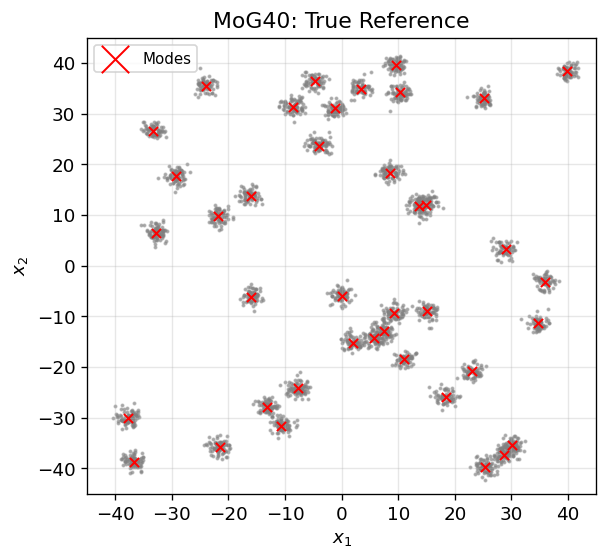

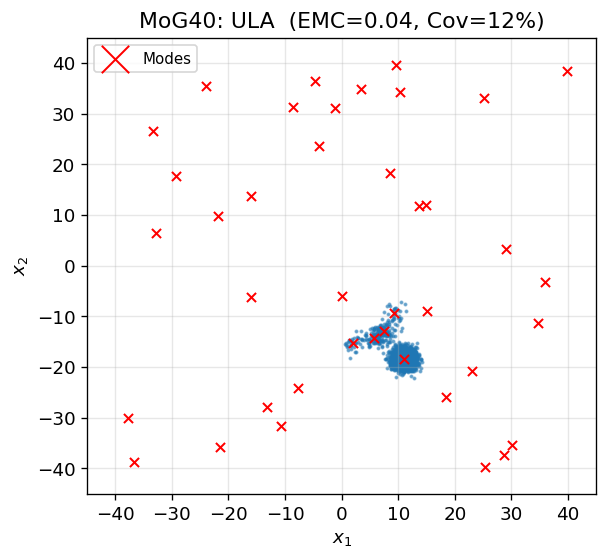

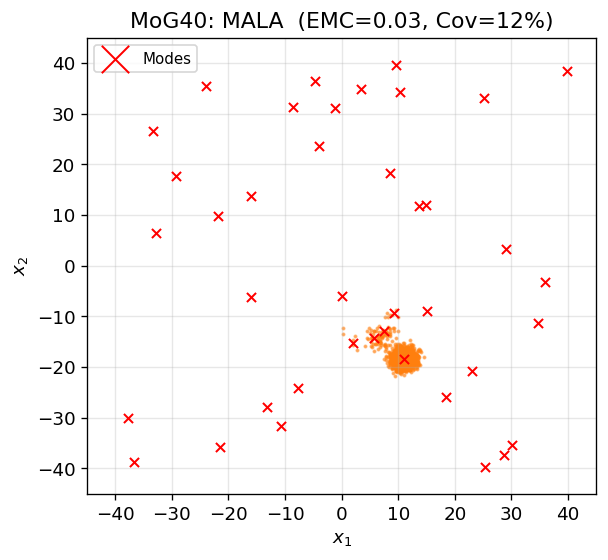

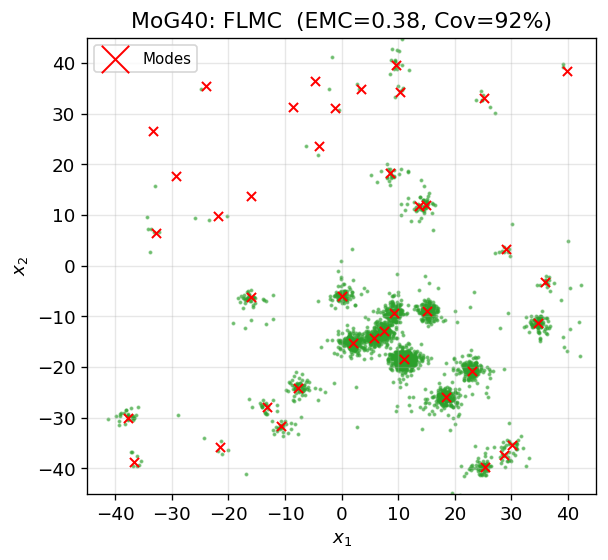

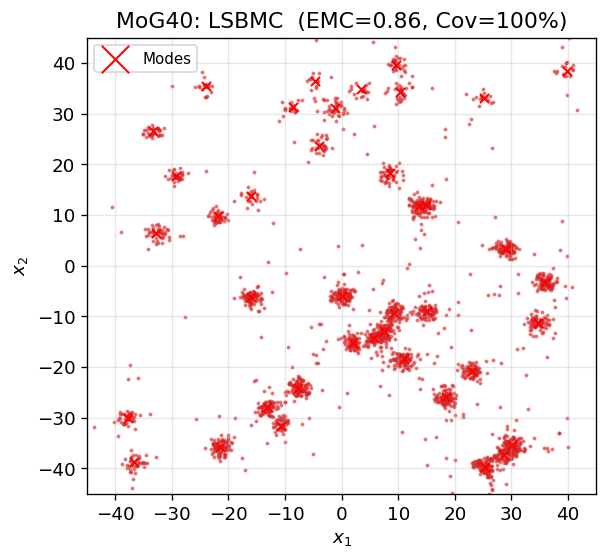

Scatter plots saved.


In [14]:
# ── Individual scatter plots (matching mog40.py style) ───────────────────────
def plot_scatter(X_samp, title, slug, color):
    fig, ax = plt.subplots(figsize=(5.2, 4.8))
    ax.scatter(X_samp[:,0], X_samp[:,1], s=2, c=color, alpha=0.5, rasterized=True)
    ax.scatter(MU[:,0], MU[:,1], marker="x", c="red", s=30, zorder=5,
               linewidths=1.2, label="Modes")
    ax.set_xlim(-45, 45); ax.set_ylim(-45, 45)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.set_title(title)
    ax.legend(markerscale=3, fontsize=9)
    fig.tight_layout()
    save_fig(fig, slug)


final_last = all_finals[-1]   # last seed

# Reference
plot_scatter(X_REF, "MoG40: True Reference", "true_scatter", "gray")

# Each sampler
for nm in NAMES:
    emc, cov, _ = hard_emc_cov(final_last[nm])
    plot_scatter(
        final_last[nm],
        f"MoG40: {nm}  (EMC={emc:.2f}, Cov={cov:.0%})",
        f"{nm.lower()}_scatter",
        COLORS[nm],
    )

print("Scatter plots saved.")


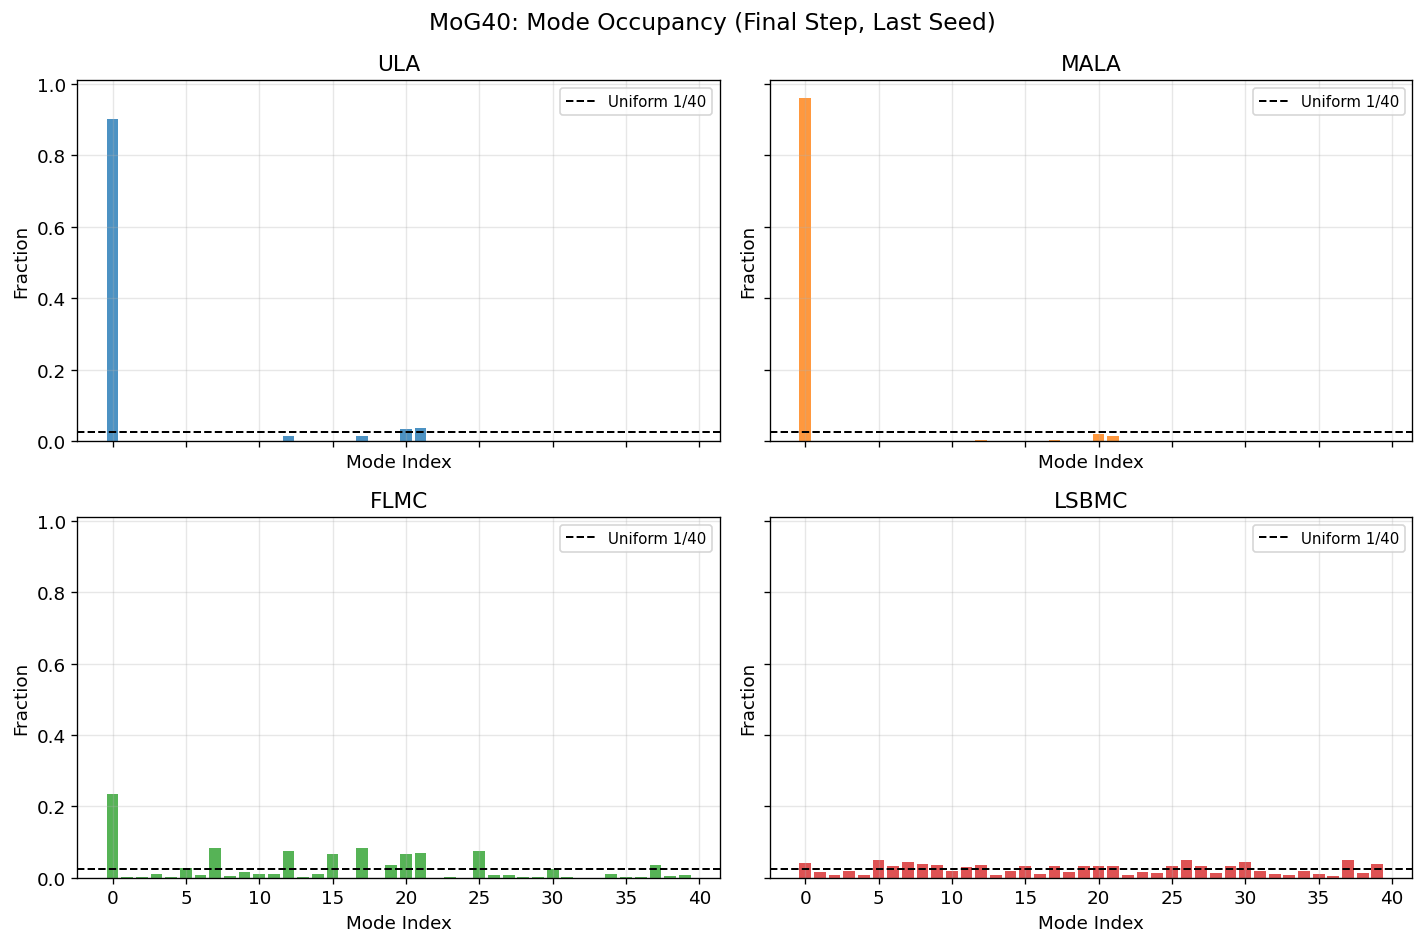

Mode occupancy saved.


In [15]:
# ── Mode occupancy 2×2 grid (matching mog40.py style) ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, nm in zip(axes.ravel(), NAMES):
    _, _, cnts = hard_emc_cov(final_last[nm])
    probs = cnts / max(cnts.sum(), 1.0)
    ax.bar(np.arange(K_MODES), probs, color=COLORS[nm], alpha=0.8, width=0.8)
    ax.axhline(1.0/K_MODES, color="k", ls="--", lw=1.2, label="Uniform 1/40")
    ax.set_title(LABELS[nm], fontsize=13)
    ax.set_xlabel("Mode Index")
    ax.set_ylabel("Fraction")
    ax.legend(fontsize=9)

fig.suptitle("MoG40: Mode Occupancy (Final Step, Last Seed)", fontsize=14)
fig.tight_layout()
save_fig(fig, "mode_occupancy_mog40")
print("Mode occupancy saved.")


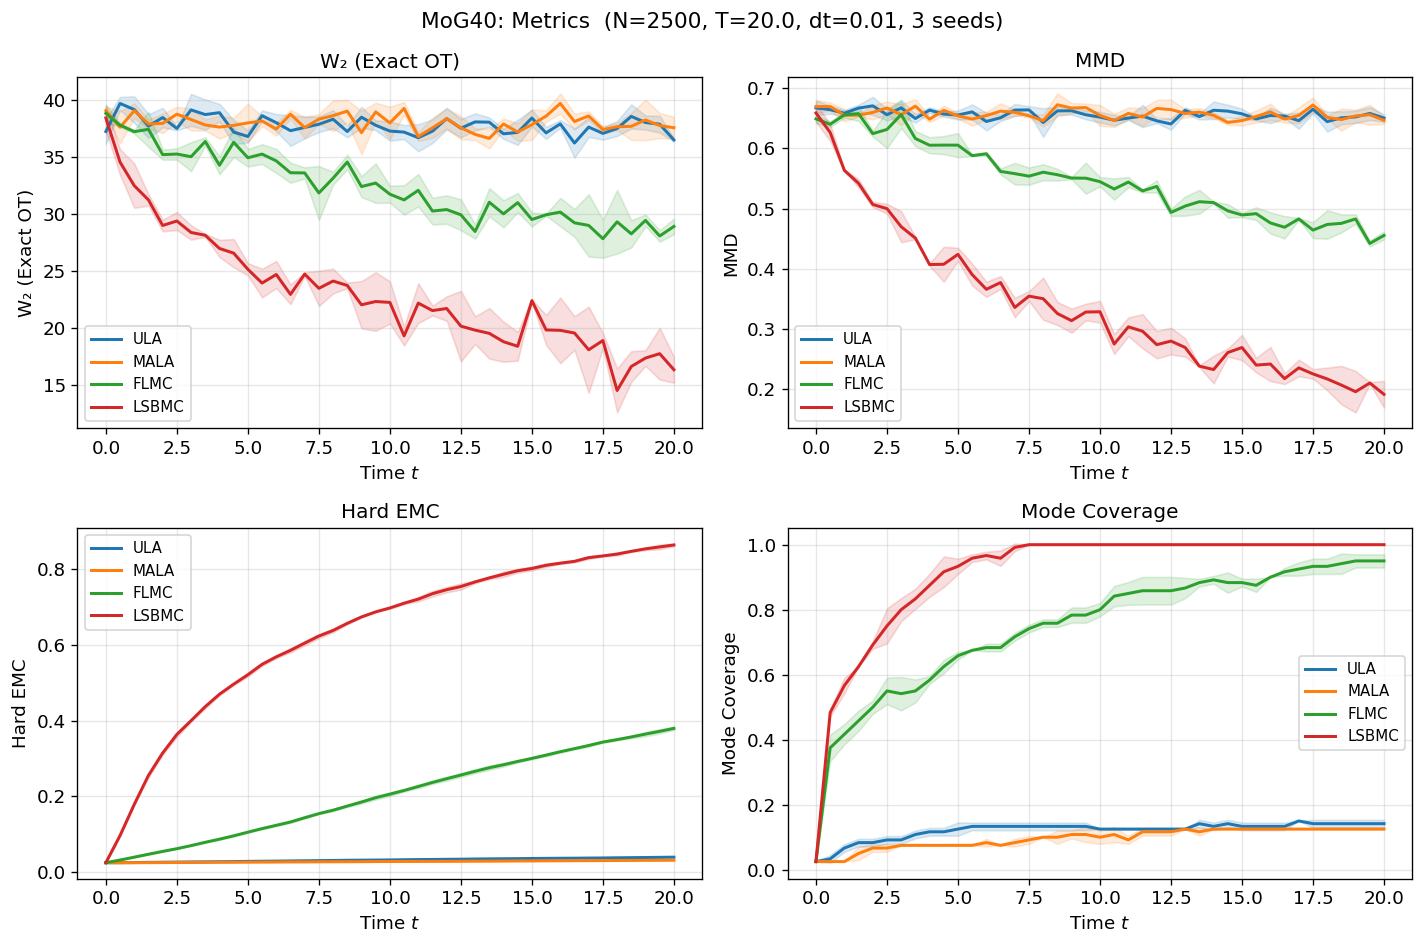

Benchmark metrics saved.


In [16]:
# ── Benchmark metrics figure (matching mog40.py style) ───────────────────────
metric_keys   = ["w2", "mmd", "emc", "cov"]
metric_labels = {
    "w2":  "W₂ (Exact OT)",
    "mmd": "MMD",
    "emc": "Hard EMC",
    "cov": "Mode Coverage",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, key in zip(axes.ravel(), metric_keys):
    for nm in NAMES:
        y    = np.array(H[nm][key])
        yerr = np.array(H[nm][key+"_std"])
        ax.plot(t_ax, y, label=nm, color=COLORS[nm], lw=1.8)
        ax.fill_between(t_ax, y-yerr, y+yerr, alpha=0.15, color=COLORS[nm])
    ax.set_xlabel("Time $t$", fontsize=11)
    ax.set_ylabel(metric_labels[key], fontsize=11)
    ax.set_title(metric_labels[key], fontsize=12)
    ax.legend(fontsize=9)

fig.suptitle(
    f"MoG40: Metrics  (N={N_PARTICLES}, T={T_END}, "
    f"dt={DT}, {len(SEEDS)} seeds)",
    fontsize=13,
)
fig.tight_layout()
save_fig(fig, "benchmark_metrics_mog40")
print("Benchmark metrics saved.")


In [17]:
# ── Summary table ────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(f"{'Method':<10} {'W2 (final)':>12} {'MMD':>10} {'EMC':>10} {'Coverage':>12}")
print("="*70)
for nm in NAMES:
    print(f"{nm:<10} {H[nm]['w2'][-1]:12.3f} {H[nm]['mmd'][-1]:10.4f} "
          f"{H[nm]['emc'][-1]:10.3f} {H[nm]['cov'][-1]:12.3f}")
print("="*70)
print(f"\nAll figures saved to: {OUT_DIR}/")


Method       W2 (final)        MMD        EMC     Coverage
ULA              36.490     0.6504      0.040        0.142
MALA             37.561     0.6465      0.032        0.125
FLMC             28.895     0.4554      0.380        0.950
LSBMC            16.316     0.1914      0.864        1.000

All figures saved to: mog40_output/
